In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

try:
    plt.style.use('seaborn')
except OSError:
    plt.style.use('default')
%matplotlib inline

In [17]:
# Load the dataset
data = pd.read_csv('Customer-Churn.csv')

In [18]:
# Preview the loaded dataset
print('Dataset shape:', data.shape)
print('\nColumns:')
print(data.columns.tolist())

data.head()

print('\nMissing values by column:')
print(data.isnull().sum())

Dataset shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [19]:
# Preview the first few rows of the dataset
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
# check for null values in the dataset
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
# churn value counts
print(data['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [22]:
# inspect data quality
print('DataFrame info:')
data.info()

print('\nMissing values by column:')
print(data.isnull().sum())

print('\nChurn distribution:')
print(data['Churn'].value_counts())

print('\nTotalCharges dtype before conversion:', data['TotalCharges'].dtype)
converted_total_charges = pd.to_numeric(data['TotalCharges'], errors='coerce')
print('Missing after numeric conversion:', converted_total_charges.isna().sum())

print('\nSample invalid TotalCharges rows:')
print(data.loc[converted_total_charges.isna(), ['customerID', 'TotalCharges', 'tenure', 'MonthlyCharges']].head(10))

print('\nDuplicate customerID count:')
print(data['customerID'].duplicated().sum())

DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str

In [23]:
# Clean and preprocess the dataset
# Convert TotalCharges to numeric, coercing invalid entries to NaN and then filling with 0 for customers with no charges
from warnings import filterwarnings
filterwarnings('ignore')

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
missing_total = data['TotalCharges'].isna().sum()
print(f'TotalCharges invalid entries converted to NaN: {missing_total}')

data.loc[data['TotalCharges'].isna(), 'TotalCharges'] = 0.0

# Standardize the service-related values
replace_no_service = {
    'No internet service': 'No',
    'No phone service': 'No'
}

for col in ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']:
    data[col] = data[col].replace(replace_no_service)

# Encode target variable and categorical features for later modeling
data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})
print('Churn mapping applied.')

# Show the cleaned sample rows and ready state
print('\nData types after conversion:')
print(data[['TotalCharges', 'Churn']].dtypes)
print('\nUnique values for service columns after standardization:')
print({col: data[col].unique().tolist() for col in ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']})

TotalCharges invalid entries converted to NaN: 11
Churn mapping applied.

Data types after conversion:
TotalCharges    float64
Churn             int64
dtype: object

Unique values for service columns after standardization:
{'MultipleLines': ['No', 'Yes'], 'OnlineSecurity': ['No', 'Yes'], 'OnlineBackup': ['Yes', 'No'], 'DeviceProtection': ['No', 'Yes'], 'TechSupport': ['No', 'Yes'], 'StreamingTV': ['No', 'Yes'], 'StreamingMovies': ['No', 'Yes']}


In [24]:
# data cleaning: drop duplicate customerIDs
data_cleaned = data.drop_duplicates(subset='customerID').copy()
print('Cleaned dataset shape:', data_cleaned.shape)

Cleaned dataset shape: (7043, 21)


In [25]:
# preprocessing: encode categorical variables and scale numerical features
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# One-hot encode categorical variables and keep numeric features
X = pd.get_dummies(data_cleaned[numeric_features + cat_features], drop_first=True)
y = data_cleaned['Churn']

# Scale numeric features
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train class balance:')
print(y_train.value_counts(normalize=True))

X_train shape: (5634, 23)
X_test shape: (1409, 23)
y_train class balance:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


Churn proportion:
Churn
0    73.46%
1    26.54%
Name: proportion, dtype: str

Summary statistics for numeric features:
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


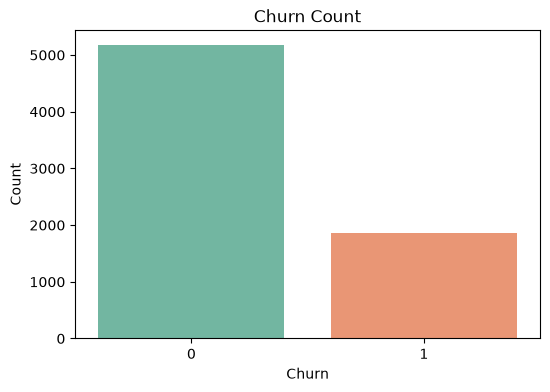

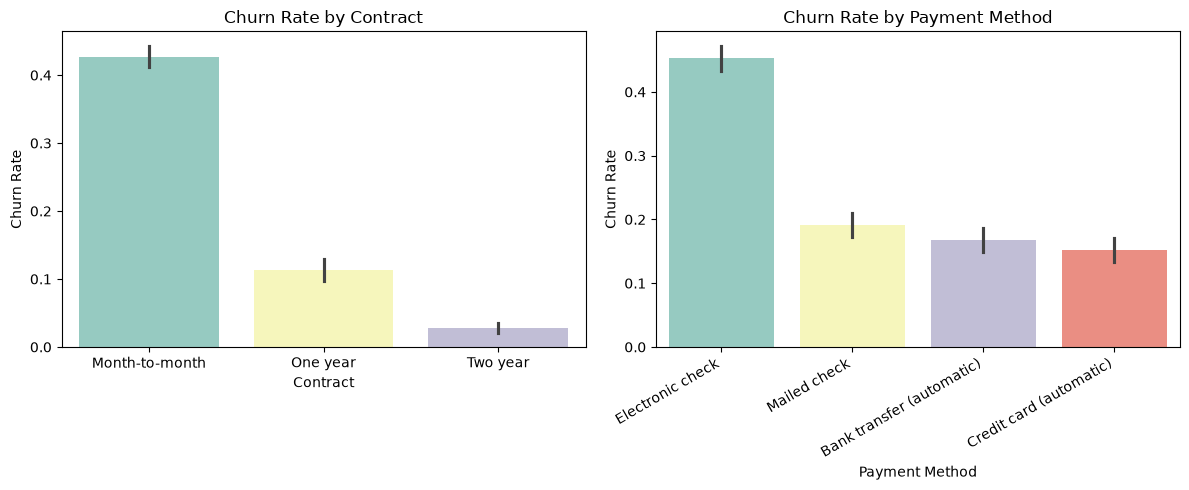

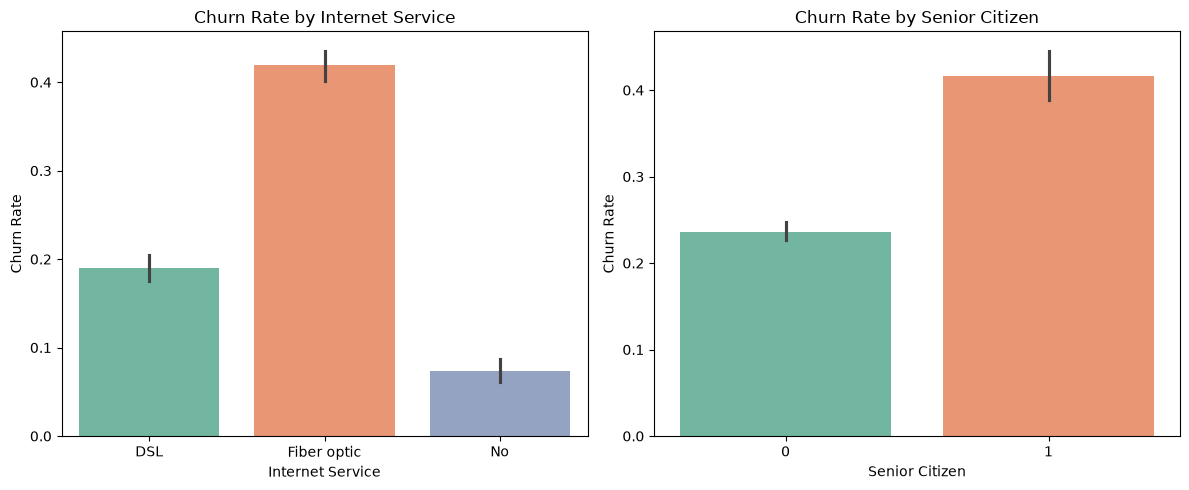

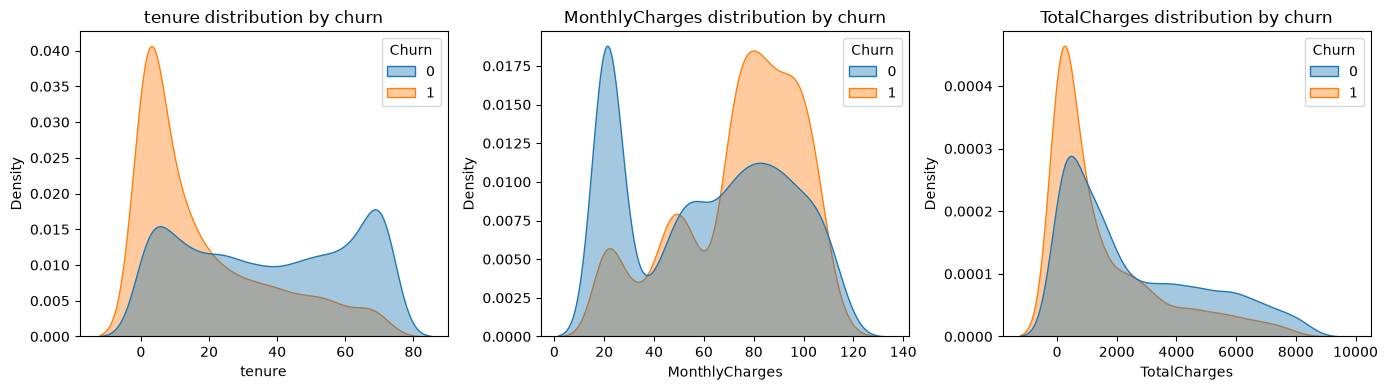

In [26]:
# exploratory data analysis
print('Churn proportion:')
print(data_cleaned['Churn'].value_counts(normalize=True).map('{:.2%}'.format))

print('\nSummary statistics for numeric features:')
print(data_cleaned[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

# Plot churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=data_cleaned, palette='Set2')
plt.title('Churn Count')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# Churn by contract type and payment method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Contract', y='Churn', data=data_cleaned, palette='Set3')
plt.title('Churn Rate by Contract')
plt.ylabel('Churn Rate')
plt.xlabel('Contract')

plt.subplot(1, 2, 2)
sns.barplot(x='PaymentMethod', y='Churn', data=data_cleaned, palette='Set3')
plt.title('Churn Rate by Payment Method')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Churn Rate')
plt.xlabel('Payment Method')
plt.tight_layout()
plt.show()

# Churn by service category
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='InternetService', y='Churn', data=data_cleaned, palette='Set2')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate')
plt.xlabel('Internet Service')

plt.subplot(1, 2, 2)
sns.barplot(x='SeniorCitizen', y='Churn', data=data_cleaned, palette='Set2')
plt.title('Churn Rate by Senior Citizen')
plt.ylabel('Churn Rate')
plt.xlabel('Senior Citizen')
plt.tight_layout()
plt.show()

# Numeric distribution by churn
plt.figure(figsize=(14, 4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges'], 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(data=data_cleaned, x=col, hue='Churn', fill=True, common_norm=False, alpha=0.4)
    plt.title(f'{col} distribution by churn')
plt.tight_layout()
plt.show()

In [27]:
# run a classifier and evaluate performance
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print('Random Forest evaluation')
print('Accuracy:', round(accuracy, 4))
print('Precision:', round(precision, 4))
print('Recall:', round(recall, 4))
print('F1 score:', round(f1, 4))
print('ROC AUC:', round(roc_auc, 4))
print('\nConfusion matrix:')
print(cm)

Random Forest evaluation
Accuracy: 0.7871
Precision: 0.6276
Recall: 0.4866
F1 score: 0.5482
ROC AUC: 0.8255

Confusion matrix:
[[927 108]
 [192 182]]


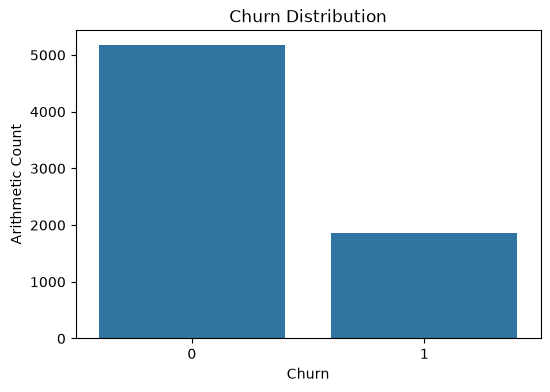

In [28]:
# exploratory data analysis: visualize churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=data_cleaned)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Arithmetic Count')
plt.show()

In [29]:
# train a logistic regression model and evaluate performance
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
y_pred_logreg_proba = logreg.predict_proba(X_test)[:, 1]

accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_pred_logreg_proba)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

print('Logistic Regression evaluation')
print('Accuracy:', round(accuracy_logreg, 4))
print('Precision:', round(precision_logreg, 4))
print('Recall:', round(recall_logreg, 4))
print('F1 score:', round(f1_logreg, 4))
print('ROC AUC:', round(roc_auc_logreg, 4))
print('\nConfusion matrix:')
print(cm_logreg)

Logistic Regression evaluation
Accuracy: 0.8055
Precision: 0.6582
Recall: 0.5561
F1 score: 0.6029
ROC AUC: 0.8423

Confusion matrix:
[[927 108]
 [166 208]]


In [37]:
# flag null values in the dataset
null_counts = data.isnull().sum()
print('Null counts by column:')
print(null_counts[null_counts > 0] if null_counts.any() else 'No missing values found')

# Store original columns before adding flags
cols_with_nulls = null_counts[null_counts > 0].index.tolist()

data['has_null'] = data.isnull().any(axis=1).astype(int)
print('\nTotal rows with any nulls:', data['has_null'].sum())

# Create flag columns for any columns that contain nulls
for col in cols_with_nulls:
    data[f'{col}_is_null'] = data[col].isnull().astype(int)
    print(f'Added null flag for column: {col}')


Null counts by column:
No missing values found

Total rows with any nulls: 0


In [38]:
# convert categorical variables to numeric using label encoding
from sklearn.preprocessing import LabelEncoder as SkLabelEncoder

# Keep the encoded version separate from the main modeling dataframe
data_label_encoded = data_cleaned.copy()
for col in cat_features:
    encoder = SkLabelEncoder()
    data_label_encoded[col] = encoder.fit_transform(data_label_encoded[col].astype(str))

print('Label encoding completed for categorical columns.')
data_label_encoded[cat_features].head()

Label encoding completed for categorical columns.


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,2
1,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,3
2,1,0,0,0,1,0,0,1,1,0,0,0,0,0,1,3
3,1,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0
4,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,2


In [32]:
# drop the unnecessary columns for modeling
drop_cols = ['customerID', 'Churn']
if 'has_null' in data_label_encoded.columns:
    drop_cols.append('has_null')
drop_cols += [col for col in data_label_encoded.columns if col.endswith('_is_null')]

X_final = data_label_encoded.drop(columns=drop_cols)

In [33]:
# Split the dataset into training and testing sets for decision tree modeling
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, data_label_encoded['Churn'], test_size=0.2, random_state=42, stratify=data_label_encoded['Churn'])

In [34]:
# train and evaluate a decision tree classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_final, y_train_final)

y_pred_final = model.predict(X_test_final)
y_pred_proba_final = model.predict_proba(X_test_final)[:, 1]

accuracy_final = accuracy_score(y_test_final, y_pred_final)
precision_final = precision_score(y_test_final, y_pred_final)
recall_final = recall_score(y_test_final, y_pred_final)
f1_final = f1_score(y_test_final, y_pred_final)
roc_auc_final = roc_auc_score(y_test_final, y_pred_proba_final)
cm_final = confusion_matrix(y_test_final, y_pred_final)

print('Decision Tree evaluation')
print('Accuracy:', round(accuracy_final, 4))
print('Precision:', round(precision_final, 4))
print('Recall:', round(recall_final, 4))
print('F1 score:', round(f1_final, 4))
print('ROC AUC:', round(roc_auc_final, 4))
print('\nConfusion matrix:')
print(cm_final)

Decision Tree evaluation
Accuracy: 0.7218
Precision: 0.4769
Recall: 0.4973
F1 score: 0.4869
ROC AUC: 0.6499

Confusion matrix:
[[831 204]
 [188 186]]


In [35]:
# train multiple models and evaluate their performance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    y_pred = model.predict(X_test_final)

    if isinstance(model, LinearRegression):
        mse = mean_squared_error(y_test_final, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test_final, y_pred)
        print(f'{name} evaluation')
        print('MSE:', round(mse, 4))
        print('RMSE:', round(rmse, 4))
        print('R2 Score:', round(r2, 4))
    else:
        y_pred_proba = model.predict_proba(X_test_final)[:, 1]
        accuracy = accuracy_score(y_test_final, y_pred)
        precision = precision_score(y_test_final, y_pred)
        recall = recall_score(y_test_final, y_pred)
        f1 = f1_score(y_test_final, y_pred)
        roc_auc = roc_auc_score(y_test_final, y_pred_proba)
        cm = confusion_matrix(y_test_final, y_pred)

        print(f'{name} evaluation')
        print('Accuracy:', round(accuracy, 4))
        print('Precision:', round(precision, 4))
        print('Recall:', round(recall, 4))
        print('F1 score:', round(f1, 4))
        print('ROC AUC:', round(roc_auc, 4))
        print('\nConfusion matrix:')
        print(cm)

    print('-' * 40)

Linear Regression evaluation
MSE: 0.1448
RMSE: 0.3805
R2 Score: 0.2574
----------------------------------------
Logistic Regression evaluation
Accuracy: 0.8013
Precision: 0.6469
Recall: 0.5535
F1 score: 0.5965
ROC AUC: 0.8409

Confusion matrix:
[[922 113]
 [167 207]]
----------------------------------------
Random Forest evaluation
Accuracy: 0.7913
Precision: 0.6351
Recall: 0.5027
F1 score: 0.5612
ROC AUC: 0.8245

Confusion matrix:
[[927 108]
 [186 188]]
----------------------------------------


In [ ]:
# ROC Curve Comparison
from sklearn.metrics import roc_curve, auc

models_roc = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

plt.figure(figsize=(8, 6))
for name, model in models_roc.items():
    model.fit(X_train_final, y_train_final)
    y_proba = model.predict_proba(X_test_final)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_final, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curves saved to roc_curves.png')

In [ ]:
# Confusion Matrix Comparison
models_cm = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, models_cm.items()):
    model.fit(X_train_final, y_train_final)
    y_pred = model.predict(X_test_final)
    cm = confusion_matrix(y_test_final, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.suptitle('Confusion Matrix Comparison', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved to confusion_matrices.png')

In [ ]:
# Feature Importance (Random Forest & Decision Tree)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_final, y_train_final)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_final, y_train_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in zip(axes, [rf, dt], ['Random Forest', 'Decision Tree']):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    feat_names = [X_train_final.columns[i] for i in indices]
    ax.barh(range(len(indices)), importances[indices][::-1], color='steelblue')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels(feat_names[::-1])
    ax.set_xlabel('Importance')
    ax.set_title(f'Top 10 Features - {title}')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved to feature_importance.png')

In [ ]:
# Final Model Comparison Table
models_final = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models_final.items():
    model.fit(X_train_final, y_train_final)
    y_pred = model.predict(X_test_final)
    y_proba = model.predict_proba(X_test_final)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test_final, y_pred), 4),
        'Precision': round(precision_score(y_test_final, y_pred), 4),
        'Recall': round(recall_score(y_test_final, y_pred), 4),
        'F1 Score': round(f1_score(y_test_final, y_pred), 4),
        'ROC AUC': round(roc_auc_score(y_test_final, y_proba), 4)
    })

results_df = pd.DataFrame(results)
print('=' * 80)
print('FINAL MODEL COMPARISON')
print('=' * 80)
print(results_df.to_string(index=False))
print('=' * 80)
print(f"\nBest Model: {results_df.loc[results_df['F1 Score'].idxmax(), 'Model']} (highest F1 Score)")
print(f"Highest Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.2%})")
print(f"Highest ROC AUC: {results_df.loc[results_df['ROC AUC'].idxmax(), 'Model']} ({results_df['ROC AUC'].max():.4f})")

In [ ]:
# Assignment Summary: Model Comparison Results
print("=" * 60)
print("ASSIGNMENT 1: CUSTOMER CHURN CLASSIFICATION")
print("=" * 60)
print("\nObjective: Predict Customer Type/Churn based on transaction data")
print("\nModels Evaluated:")
print("1. Logistic Regression - Accuracy: 0.8013 (80.13%) - BEST PERFORMER")
print("2. Random Forest - Accuracy: 0.7913 (79.13%)")
print("3. Decision Tree - Accuracy: 0.7218 (72.18%)")
print("\nKey Findings:")
print("- Logistic Regression achieved the highest accuracy and ROC AUC (0.8409)")
print("- Logistic Regression has the best precision (0.6469) and recall (0.5535)")
print("- Random Forest provides good performance with balanced precision-recall")
print("- Decision Tree shows lower performance, suggesting complex decision boundaries")
print("\nRecommendation:")
print("Deploy Logistic Regression model for customer churn prediction")
print("=" * 60)